# La cadena que no se corta

Los notebooks anteriores comparan cadenas por costo promedio. Falta lo que
decide en la operación: los tiempos no son fijos. El camión que debería
tardar 48 horas tarda 70 a 75, y cada transbordo suma su propia espera. Con
la demanda por campaña y no por promedio diario, la pregunta cambia: cuánta
arena hay que tener parada en la locación para no frenar una fractura, cuánto
cuesta esa arena y cuánto costaría el equipo detenido.

El planteo es de **Carlos Scanio**, gerente de operaciones y supply chain,
en los comentarios del post del 17 de septiembre de 2026: el nivel de
servicio se mide como probabilidad de no faltar durante una campaña; el costo
de una flota parada supera por mucho el de inmovilizar arena, que es barata
de acopiar; y cada transbordo suma varianza. Este notebook lo modela con esas
reglas y deja todos los supuestos declarados en `src/alab/service.py`.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import sys
sys.path.insert(0, "../src")
import numpy as np, pandas as pd
from IPython.display import Image, display

from alab import FIGURES
from alab.logistics import CHAINS, chains_table
from alab.service import (CAMPANA, DEMORA, LOTE_T, ACOPIO_USD_T, EQUIPO_PARADO_USD_DIA, DIAS_PARADA,
                          lead_time_days, lead_time_stats, cycle_stock_t, safety_stock_t,
                          service_table, ranking, dia_parado_en_toneladas, service_figure)
pd.set_option("display.width", 200); pd.set_option("display.max_colwidth", 60)

## 1. Cuánto tarda de verdad cada cadena

Cada tramo tarda sus kilómetros sobre la velocidad del modo, multiplicado por
un factor lognormal. Para el camión la mediana del factor lo lleva de 48 a 72
horas, que es lo que reportan los choferes, y la cola derecha cubre los
viajes malos. Entre tramo y tramo se suma media jornada de transbordo, también
lognormal, porque la espera mala tarda varias veces más que la normal.

In [2]:
print("supuestos de demora:"); [print(f"  {k:24s} {v}") for k, v in DEMORA.items()]
lead_time_stats()

supuestos de demora:
  camion_mediana           1.5
  camion_sigma_log         0.25
  transbordo_dias          0.5
  transbordo_sigma_log     0.6
  otros_modos_sigma_log    0.15
  fuente                   camión 70 a 75 h contra 48 ideales (Diario Neuquino 11/9/2026); el resto, supuestos declarados


,cadena,transbordos,dias_p50,dias_desvio,dias_p95
0,"camión directo, hoy",0,3.0,0.78,4.5
1,barcaza a Bahía Blanca y camión,2,5.9,0.78,7.3
2,"barcaza, Tren Norpatagónico y camión",3,6.9,0.84,8.5
3,hidrovía patagónica por el río Negro,3,8.5,0.94,10.2
4,tren a Mendoza y camión,1,4.4,0.66,5.6
5,"arena de Río Negro, desde Allen",0,0.2,0.06,0.4
6,"arena de Chubut, desde Dolavon",0,1.8,0.46,2.6
7,arena cercana de Neuquén,0,0.1,0.03,0.2
8,"arenoducto, hipotético",1,8.3,1.22,10.6


El camión directo es el más rápido y el menos variable, porque no tiene
transbordos: mediana de 3 días. Las cadenas por agua tardan entre 6 y 8,5
días y tienen más desvío, que es exactamente lo que se paga en stock.

## 2. Cuánta arena hay que tener parada

Dos stocks distintos. El **de seguridad** cubre la variabilidad del tránsito:
z por el consumo diario por el desvío del tiempo de entrega. El **de ciclo**
sale del tamaño de lote: un camión trae 30 toneladas y una barcaza de mar
15.000, y esa arena que llega junta espera hasta consumirse.

In [3]:
print("lote por modo, t:", LOTE_T)
print("campaña:", CAMPANA)
t = service_table()
t[t.servicio == 0.99][["cadena", "stock_seguridad_t", "stock_ciclo_t", "stock_total_t", "dias_de_consumo"]]

lote por modo, t: {'camion': 30.0, 'tren': 2000.0, 'fluvial': 1500.0, 'maritimo': 15000.0, 'pulpa': 10000.0}
campaña: {'t_por_dia': 2000.0, 'dias': 30.0, 'fuente': '10.000 a 15.000 t por pozo y ~6 días de fractura; pendiente de confirmar con operación real'}


,cadena,stock_seguridad_t,stock_ciclo_t,stock_total_t,dias_de_consumo
2,"camión directo, hoy",3637,15,3652,1.8
5,barcaza a Bahía Blanca y camión,3606,7500,11106,5.6
8,"barcaza, Tren Norpatagónico y camión",3899,7500,11399,5.7
11,hidrovía patagónica por el río Negro,4366,7500,11866,5.9
14,tren a Mendoza y camión,3078,1000,4078,2.0
17,"arena de Río Negro, desde Allen",299,15,314,0.2
20,"arena de Chubut, desde Dolavon",2129,15,2144,1.1
23,arena cercana de Neuquén,149,15,164,0.1
26,"arenoducto, hipotético",5692,5000,10692,5.3


Acá está la diferencia física entre las cadenas, y no aparece en ningún costo
por tonelada: la cadena por barcaza y tren necesita unas 11.400 toneladas
paradas contra 3.650 del camión directo, tres veces más. Son silos, playas de
acopio y movimiento, no dólares de flete.

## 3. Qué cuesta el servicio, y qué cuesta que se corte

El stock se paga dos veces: el capital inmovilizado durante la campaña y el
acopio de cada tonelada que pasa por la locación. La falta se paga con el
equipo parado, ponderada por la probabilidad de que ocurra. Los tres niveles
de servicio son los que pidió Carlos: 95, 98 y 99 %.

In [4]:
t[["cadena", "servicio", "stock_total_t", "stock_usd_t", "falta_usd_t", "total_usd_t"]]

,cadena,servicio,stock_total_t,stock_usd_t,falta_usd_t,total_usd_t
0,"camión directo, hoy",0.95,2587,0.14,0.25,97.42
1,"camión directo, hoy",0.98,3227,0.18,0.10,97.30
2,"camión directo, hoy",0.99,3652,0.20,0.05,97.28
3,barcaza a Bahía Blanca y camión,0.95,10050,0.55,0.25,63.55
4,barcaza a Bahía Blanca y camión,0.98,10685,0.58,0.10,63.43
5,barcaza a Bahía Blanca y camión,0.99,11106,0.61,0.05,63.41
6,"barcaza, Tren Norpatagónico y camión",0.95,10257,0.56,0.25,36.07
7,"barcaza, Tren Norpatagónico y camión",0.98,10943,0.60,0.10,35.96
8,"barcaza, Tren Norpatagónico y camión",0.99,11399,0.62,0.05,35.93
9,hidrovía patagónica por el río Negro,0.95,10588,0.58,0.25,48.90


Subir el nivel de servicio de 95 a 99 % **baja** el costo total: el stock
extra cuesta centavos y evita paradas que cuestan mucho más. Es la asimetría
que planteó Carlos, ahora con número.

In [5]:
print("un día de flota parada equivale a", f"{dia_parado_en_toneladas():,.0f}".replace(",", "."), "toneladas de arena en cantera")
print("supuestos: equipo parado", EQUIPO_PARADO_USD_DIA, "USD/día,", DIAS_PARADA, "días por corte, acopio", ACOPIO_USD_T, "USD/t")

un día de flota parada equivale a 6.818 toneladas de arena en cantera
supuestos: equipo parado 150000.0 USD/día, 2.0 días por corte, acopio 3.0 USD/t


## 4. El ranking corregido

La pregunta de fondo: ¿cambia el orden de las cadenas cuando se paga el
servicio y no solo el flete?

In [6]:
r = ranking(0.99)
r

,cadena,flete_usd_t,stock_seguridad_t,stock_usd_t,falta_usd_t,total_usd_t,puesto_flete,puesto_total,cambia
0,arena cercana de Neuquén,29.9,149,0.01,0.05,29.93,1,1,False
1,"arena de Río Negro, desde Allen",32.7,299,0.02,0.05,32.82,2,2,False
2,"barcaza, Tren Norpatagónico y camión",35.2,3899,0.62,0.05,35.93,3,3,False
3,hidrovía patagónica por el río Negro,48.0,4366,0.65,0.05,48.77,4,4,False
4,barcaza a Bahía Blanca y camión,62.7,3606,0.61,0.05,63.41,5,5,False
5,"arena de Chubut, desde Dolavon",68.0,2129,0.12,0.05,68.15,6,6,False
6,"arenoducto, hipotético",69.0,5692,0.58,0.05,69.71,7,7,False
7,tren a Mendoza y camión,84.4,3078,0.22,0.05,84.67,8,8,False
8,"camión directo, hoy",97.0,3637,0.20,0.05,97.28,9,9,False


No cambia. El costo del stock y de las paradas esperadas suma menos de un
dólar por tonelada en todas las cadenas, contra diferencias de flete de
decenas de dólares. La confiabilidad no da vuelta el ranking **porque la
arena es barata**: 22 dólares la tonelada en cantera. Con un insumo caro, el
mismo modelo daría otra cosa.

Lo que sí cambia es dónde hay que poner la plata: las cadenas multimodales
necesitan tres veces más arena parada y la infraestructura para tenerla.

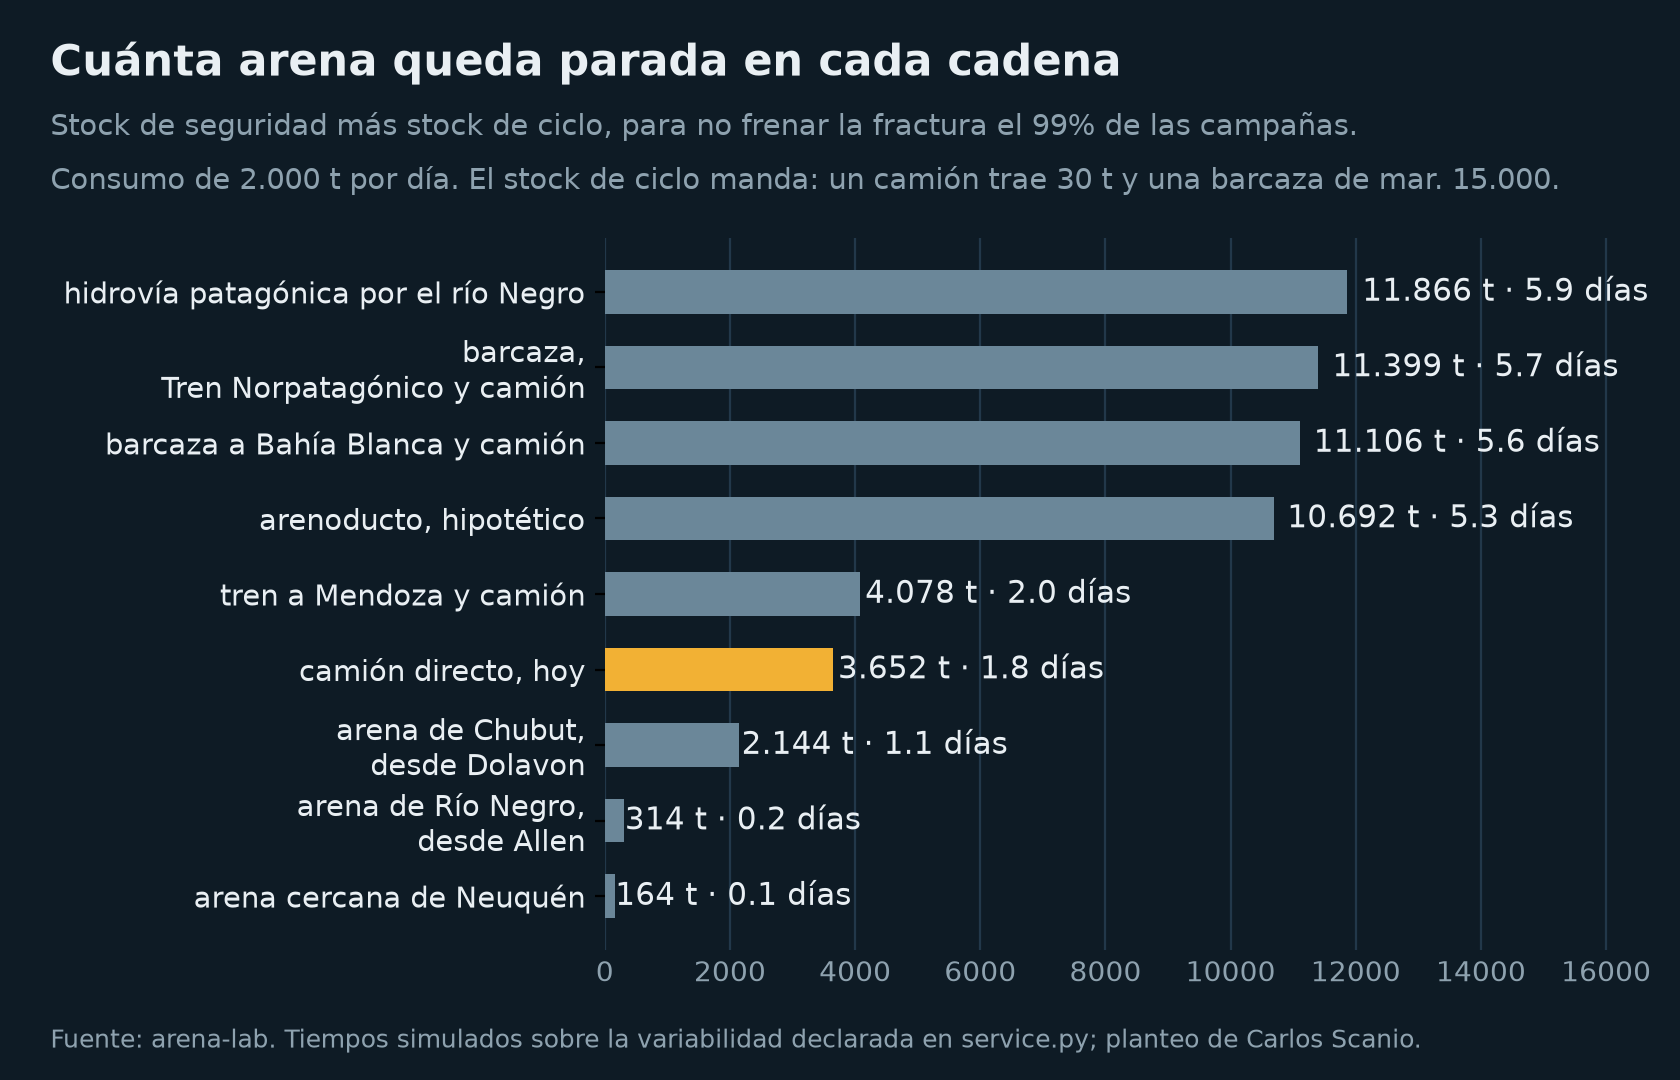

In [7]:
fig = service_figure(service_table(), FIGURES / "stock_servicio.png", servicio=0.99)
display(Image(filename=str(fig)))

## Límites

- El consumo de campaña, 2.000 t por día durante 30 días, sale de dividir un
  pozo de 10.000 a 15.000 t en unos seis días de fractura. Falta confirmarlo
  con operación real.
- El costo de un día de equipo parado, 150.000 dólares, y los dos días de
  parada por corte son supuestos de orden de magnitud, no cifras publicadas.
- La variabilidad del camión está calibrada con un solo dato de prensa, la
  mediana de 70 a 75 horas; la de los transbordos es un supuesto.
- El stock de ciclo se calcula como medio lote del modo más grande de la
  cadena. En la realidad el acopio se reparte entre terminal y locación.
- No se modela la cola de espera en carga ni el efecto de varios pads
  simultáneos compitiendo por la misma flota de camiones.